<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/_energy_track/E1_Multivariate_Demand_Lags.ipynb)

# Multivariate Window Method: Electricity Demand
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

The window method again - but now the past isn't just the target's own history. Every hour we know the **weather** and the **clock** too. Build lag columns for demand *and* its covariates, hand the flat table to a dense net, and see what the weather adds on top of "what did demand do last hour?".

*Energy-track version of the room-occupancy lags notebook: same idea, a regression target you can read in megawatts.*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 8B — Multivariate window method: electricity demand
- Same window method as the temperature notebook, but the covariates come along: temperature, dew point, humidity, and the clock as sin/cos.
- The file is UNSORTED - show it. Train 2018 / test 2019, chronological, no shuffle.
- Lag the target AND the covariates with shift(1..k). Here lagged demand is legitimate (that IS the forecast problem) - contrast with occupancy where lagged occupancy would be cheating.
- Baselines first: mean-only, seasonal naive, persistence. Persistence at one hour ahead is the villain.
- Two dense nets: demand lags only (~47 MW) vs demand + weather lags (~60 MW). The weather HURTS here - 96 lag columns of mostly-noise for a dense net to weigh - and persistence is 129. Say why: one hour ahead, last hour already carries the weather.
- Close with the two plots that keep you honest: the 45-degree scatter AND the time-series overlay.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Input, Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Read, sort, split

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("in date order as delivered?", df["Datetime"].is_monotonic_increasing)      # it is NOT - always check
df = df.sort_values("Datetime").set_index("Datetime").ffill()

# two years is plenty for the lecture: train on 2018, test on 2019 - chronological, never shuffled
data  = df.loc["2018-01-01":"2019-12-31", ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "Demand"]].copy()
data["hour_sin"] = np.sin(2*np.pi*data.index.hour/24); data["hour_cos"] = np.cos(2*np.pi*data.index.hour/24)
data["dow_sin"]  = np.sin(2*np.pi*data.index.dayofweek/7); data["dow_cos"] = np.cos(2*np.pi*data.index.dayofweek/7)
data = data[["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]]   # Demand LAST
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)
data.head()

in date order as delivered? False
train: (8760, 8) | test: (8760, 8)


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
Datetime,,,,,,,,
2018-01-01 00:00:00,1.9,0.0,56.85,0.000000,1.000000,0.0,1.0,3867.09
2018-01-01 01:00:00,0.0,0.0,62.12,0.258819,0.965926,0.0,1.0,3749.96
2018-01-01 02:00:00,0.0,0.0,61.38,0.500000,0.866025,0.0,1.0,3673.50
2018-01-01 03:00:00,0.0,0.0,71.11,0.707107,0.707107,0.0,1.0,3646.25
2018-01-01 04:00:00,0.0,0.0,64.21,0.866025,0.500000,0.0,1.0,3660.86


## Baselines first

In [3]:
y = test["Demand"]
baselines = pd.Series({
    "mean-only":                       mean_absolute_error(y, np.full(len(y), train["Demand"].mean())),
    "seasonal naive (same hour yday)": mean_absolute_error(y.iloc[24:], y.shift(24).iloc[24:]),
    "persistence (last hour)":         mean_absolute_error(y.iloc[1:],  y.shift(1).iloc[1:]),
}, name="test MAE (MW)").round(1)
baselines

mean-only                          563.3
seasonal naive (same hour yday)    227.1
persistence (last hour)            129.0
Name: test MAE (MW), dtype: float64

## Build the lag table

`shift(k)` moves a column down `k` rows, so row *t* holds the value from *k* hours ago. Do it for the target **and** the covariates, drop the rows with no history, and the sequence problem has become a flat table any model can eat.

<!-- WINDOW-FN -->
## The window-making function: `make_lags`

**This is the same idea as `series_to_supervised` from Module 4.1** - shift each column back by 1, 2, ... k rows
and line the shifted copies up side by side, then drop the rows at the start that have no history. The only
differences are cosmetic: `make_lags` names its columns `Demand_lag1 ... Demand_lag24` instead of `var1(t-1)`, and
it takes the list of columns to lag so we can build one table with demand only and another with demand + weather.

Same shape of output, same thing to remember: **one row per sample, one column per (variable, lag) pair.**

In [4]:
def make_lags(d, cols, lookback):
    out = pd.DataFrame(index=d.index)
    for c in cols:
        for k in range(1, lookback + 1):
            out[f"{c}_lag{k}"] = d[c].shift(k)
    out["target"] = d["Demand"]                      # what we predict: demand NOW, from the past k hours
    return out.dropna()

lookback = 24
lag_demand = make_lags(data, ["Demand"], lookback)                                     # 24 columns
lag_all    = make_lags(data, ["Demand", "BDL_tmpf", "BDL_dwpf", "BDL_relh"], lookback)   # 96 columns
lag_all = lag_all.join(data[["hour_sin", "hour_cos", "dow_sin", "dow_cos"]])          # the clock needs no lag - we know what time it is
lag_all = lag_all[[c for c in lag_all.columns if c != "target"] + ["target"]]
print(lag_demand.shape, lag_all.shape)
lag_all.head(3)

(17496, 25) (17496, 101)


,Demand_lag1,Demand_lag2,Demand_lag3,Demand_lag4,Demand_lag5,Demand_lag6,Demand_lag7,Demand_lag8,Demand_lag9,Demand_lag10,...,BDL_relh_lag20,BDL_relh_lag21,BDL_relh_lag22,BDL_relh_lag23,BDL_relh_lag24,hour_sin,hour_cos,dow_sin,dow_cos,target
Datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-02 00:00:00,3900.18,4166.84,4476.18,4697.43,4831.56,4882.31,4900.78,4594.62,4325.71,4259.30,...,64.21,71.11,61.38,62.12,56.85,0.000000,1.000000,0.781831,0.62349,3733.57
2018-01-02 01:00:00,3733.57,3900.18,4166.84,4476.18,4697.43,4831.56,4882.31,4900.78,4594.62,4325.71,...,61.08,64.21,71.11,61.38,62.12,0.258819,0.965926,0.781831,0.62349,3641.62
2018-01-02 02:00:00,3641.62,3733.57,3900.18,4166.84,4476.18,4697.43,4831.56,4882.31,4900.78,4594.62,...,60.91,61.08,64.21,71.11,61.38,0.500000,0.866025,0.781831,0.62349,3594.10


## A dense net on the lag table, one step at a time

No helper function here - every step is its own line so you can see what happens to the data. We do it once for
the **demand-only** table, then repeat the same seven steps for the table **with weather and the clock**.

In [5]:
scores = {}
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)

# 1. split by DATE - train on 2018, test on 2019. Never shuffle a time series.
tab = lag_demand
train_tab = tab.loc[:"2018-12-31"]
test_tab  = tab.loc["2019-01-01":]
print("train rows:", len(train_tab), " test rows:", len(test_tab))

train rows: 8736  test rows: 8760


In [6]:
# 2. scale. Fit the scalers on TRAIN ONLY, then apply to both.
#    A separate scaler for the target so we can turn predictions back into megawatts.
scX = MinMaxScaler().fit(train_tab.iloc[:, :-1])
scy = MinMaxScaler().fit(train_tab[["target"]])

X_train = scX.transform(train_tab.iloc[:, :-1])
X_test  = scX.transform(test_tab.iloc[:, :-1])
y_train = scy.transform(train_tab[["target"]]).ravel()
y_test  = test_tab["target"].values          # keep the test target in MW

print("X_train:", X_train.shape, "  X_test:", X_test.shape)

X_train: (8736, 24)   X_test: (8760, 24)


In [7]:
# 3. build the model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 4. fit it, keeping the History object
history = model.fit(X_train, y_train, epochs=40, batch_size=64,
                    validation_split=0.2, callbacks=[es], verbose=0)

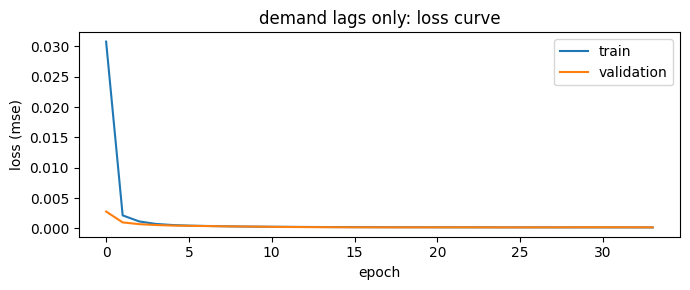

stopped after 34 epochs


In [9]:
# 5. the loss curve
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("demand lags only: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print("stopped after", len(history.history["loss"]), "epochs")

In [10]:
# 6. predict, and put the answer back into megawatts
pred_d = scy.inverse_transform(model.predict(X_test, verbose=0)).ravel()
truth  = y_test

mae_d = round(mean_absolute_error(truth, pred_d), 1)
scores["demand lags only"] = mae_d
print("demand lags only - test MAE:", mae_d, "MW")
print("persistence baseline:", round(baselines.iloc[2], 1), "MW")

dense_d = model

demand lags only - test MAE: 47.1 MW
persistence baseline: 129.0 MW


### Now the same seven steps, with weather and the clock added

Literally the same code - only the table changes, from `lag_demand` to `lag_all`. That is the experiment: does
knowing the temperature help predict demand an hour from now?

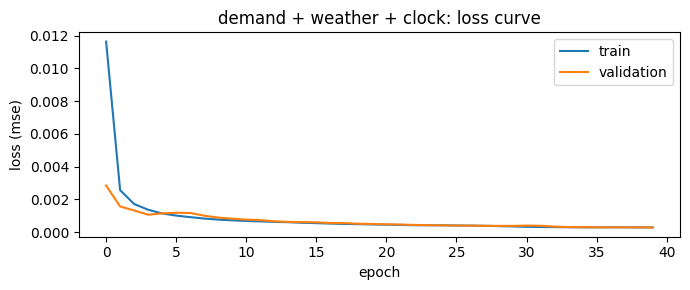

demand + weather + clock - test MAE: 60.0 MW


In [11]:
tab = lag_all
train_tab = tab.loc[:"2018-12-31"]
test_tab  = tab.loc["2019-01-01":]

scX = MinMaxScaler().fit(train_tab.iloc[:, :-1])
scy = MinMaxScaler().fit(train_tab[["target"]])
X_train = scX.transform(train_tab.iloc[:, :-1])
X_test  = scX.transform(test_tab.iloc[:, :-1])
y_train = scy.transform(train_tab[["target"]]).ravel()

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(X_train, y_train, epochs=40, batch_size=64,
                    validation_split=0.2, callbacks=[es], verbose=0)

plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("demand + weather + clock: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

pred_a = scy.inverse_transform(model.predict(X_test, verbose=0)).ravel()
mae_a = round(mean_absolute_error(truth, pred_a), 1)
scores["demand + weather + clock"] = mae_a
print("demand + weather + clock - test MAE:", mae_a, "MW")

dense_a = model

## The two honest plots

A 45-degree scatter can look perfect for a model that just repeats last hour. The time-series overlay shows whether it *leads* or *lags* reality.

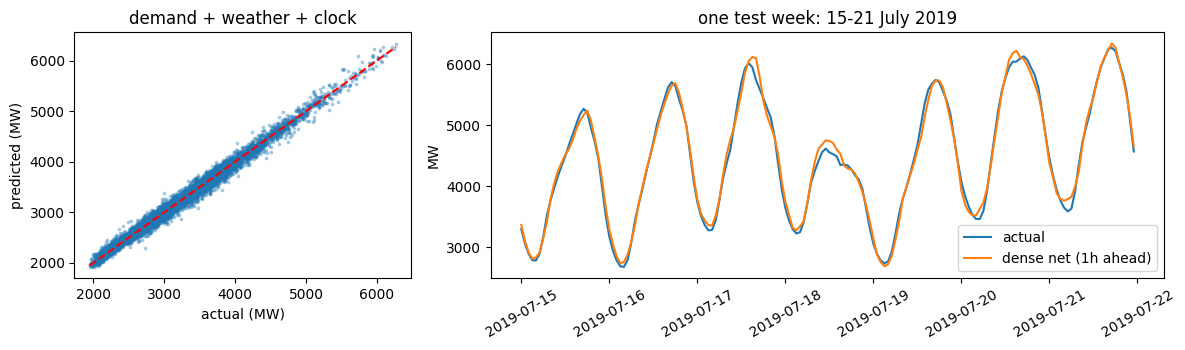

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1, 2]})

ax[0].scatter(truth, pred_a, s=3, alpha=0.3)
ax[0].plot([truth.min(), truth.max()], [truth.min(), truth.max()], "r--")
ax[0].set_xlabel("actual (MW)"); ax[0].set_ylabel("predicted (MW)")
ax[0].set_title("demand + weather + clock")

# one week of the test year, chosen by DATE so it is obvious which week we are looking at
week = test_tab.loc["2019-07-15":"2019-07-21"].index
rows = test_tab.index.get_indexer(week)
ax[1].plot(week, truth[rows], label="actual")
ax[1].plot(week, pred_a[rows], label="dense net (1h ahead)")
ax[1].set_title("one test week: 15-21 July 2019"); ax[1].set_ylabel("MW")
ax[1].tick_params(axis="x", rotation=30); ax[1].legend()

plt.tight_layout(); plt.show()

## The scoreboard

Every model next to the baselines it had to beat. The number that matters is not the MAE itself - it is the gap
between a model and **seasonal naive**, because "same hour yesterday" is free and already very good on a load
series.

In [13]:
board = pd.concat([baselines, pd.Series(scores, name="test MAE (MW)")]).sort_values().round(1)
display(board.to_frame())

best  = board.index[0]
naive = round(baselines["seasonal naive (same hour yday)"], 1)
gain  = round(100 * (naive - board.iloc[0]) / naive)
print("best:", best, "at", board.iloc[0], "MW")
print("seasonal naive:", naive, "MW  ->  the best model is", str(gain) + "% better than that baseline")

,test MAE (MW)
demand lags only,47.1
demand + weather + clock,60.0
persistence (last hour),129.0
seasonal naive (same hour yday),227.1
mean-only,563.3


best: demand lags only at 47.1 MW
seasonal naive: 227.1 MW  ->  the best model is 79% better than that baseline


## Save the model and use it again

In [14]:
dense_a.save('E1_Multivariate_Demand_Lags.keras')
reloaded = load_model('E1_Multivariate_Demand_Lags.keras')
tr = lag_all.loc[:"2018-12-31"]; scX = MinMaxScaler().fit(tr.iloc[:, :-1])
Xte = scX.transform(lag_all.loc["2019-01-01":].iloc[:5, :-1])
print("reloaded model reproduces the predictions:", np.allclose(dense_a.predict(Xte, verbose=0), reloaded.predict(Xte, verbose=0)))

reloaded model reproduces the predictions: True


## On your own

- Try `lookback = 6` and `lookback = 168` (a week). Does more history help a dense net, or just add parameters?
- Drop the demand lags entirely: weather + clock only. How bad is a forecast that never looks at demand?
- Replace the target with **demand 24 hours from now** (`shift(-24)`). Persistence stops being cheap - who wins now?